# 03 - Predictive Modelling


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("car_insurance_clean.csv", parse_dates=["incident_date"])
print("Loaded:", df.shape)

Loaded: (30000, 25)


## 1. Feature engineering


In [3]:
df["claim_to_premium"] = df["claim_amount"] / df["policy_annual_premium"]
df["total_to_claim_ratio"] = df["total_claim_amount"] / (df["claim_amount"] + 1)
df["no_witness_flag"] = (df["witnesses"] == 0).astype(int)
df["no_police_report_flag"] = (df["police_report_available"] == "No").astype(int)
df["authority_none_flag"] = (df["authorities_contacted"] == "None").astype(int)

severity_map = {"Minor Damage": 1, "Major Damage": 2, "Total Loss": 3}
df["severity_score"] = df["incident_severity"].map(severity_map)

df["incident_month"] = df["incident_date"].dt.month
df["incident_weekday"] = df["incident_date"].dt.weekday
# (incident_hour_of_the_day already exists)

print("New engineered columns added. Data shape now:", df.shape)
df[["claim_to_premium", "total_to_claim_ratio", "no_witness_flag",
    "no_police_report_flag", "authority_none_flag", "severity_score"]].head()

New engineered columns added. Data shape now: (30000, 33)


,claim_to_premium,total_to_claim_ratio,no_witness_flag,no_police_report_flag,authority_none_flag,severity_score
0,5.704133,1.430665,1,0,0,3
1,21.722653,0.971180,0,1,0,3
2,8.606416,0.966465,0,1,0,3
3,21.189743,1.076909,0,1,0,3
4,14.994610,1.099386,0,1,0,1


## 2. Choose features and target


In [ ]:
target = "fraud"
drop_cols = ["policy_id", "incident_city", "incident_date", "fraud_reported",
             "fraud"]

X = df.drop(columns=drop_cols)
y = df[target]

# Split features into numeric vs categorical
categorical = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()

print("Number of features:", X.shape[1])
print("\nCategorical features ({}):".format(len(categorical)), categorical)
print("\nNumeric features ({}):".format(len(numeric)), numeric)

Number of features: 28

Categorical features (11): ['policy_state', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'police_report_available']

Numeric features (17): ['policy_deductible', 'policy_annual_premium', 'insured_age', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount', 'claim_to_premium', 'total_to_claim_ratio', 'no_witness_flag', 'no_police_report_flag', 'authority_none_flag', 'severity_score', 'incident_month', 'incident_weekday']


C:\Users\meshw\AppData\Local\Temp\ipykernel_27340\1736999182.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = X.select_dtypes(include="object").columns.tolist()


## 3. Train / Validation / Test split (70 / 15 / 15)


In [ ]:
# First split off 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Then split the 30% into 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "fraud rate {:.1f}%".format(100 * y_train.mean()))
print("Valid:", X_val.shape, "fraud rate {:.1f}%".format(100 * y_val.mean()))
print("Test :", X_test.shape, "fraud rate {:.1f}%".format(100 * y_test.mean()))

Train: (21000, 28) fraud rate 11.5%
Valid: (4500, 28) fraud rate 11.5%
Test : (4500, 28) fraud rate 11.5%


## 4. Preprocessing


In [6]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

# The three classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                             eval_metric="logloss", random_state=RANDOM_STATE,
                             n_jobs=-1, tree_method="hist"),
}

## 5. Train all 6 models and evaluate on the validation set

In [ ]:
def evaluate(pipe, X_eval, y_eval):
    """Return a dict of metrics for a fitted pipeline on given data."""
    pred = pipe.predict(X_eval)
    proba = pipe.predict_proba(X_eval)[:, 1]
    return {
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_eval, proba),
    }


results = []
fitted = {}   # keep the fitted pipelines

for name, clf in models.items():
    for use_smote in [False, True]:
        if use_smote:
            pipe = ImbPipeline(steps=[
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=RANDOM_STATE)),
                ("clf", clf),
            ])
        else:
            pipe = ImbPipeline(steps=[
                ("prep", preprocessor),
                ("clf", clf),
            ])
        pipe.fit(X_train, y_train)
        m = evaluate(pipe, X_val, y_val)
        tag = "SMOTE" if use_smote else "Original"
        m.update({"Model": name, "Data": tag})
        results.append(m)
        fitted[(name, tag)] = pipe
        print(f"{name:20s} | {tag:8s} | "
              f"P={m['Precision']:.3f} R={m['Recall']:.3f} "
              f"F1={m['F1']:.3f} AUC={m['AUC-ROC']:.3f}")

Logistic Regression  | Original | P=0.364 R=0.016 F1=0.030 AUC=0.698
Logistic Regression  | SMOTE    | P=0.207 R=0.612 F1=0.310 AUC=0.695
Random Forest        | Original | P=0.333 R=0.004 F1=0.008 AUC=0.740
Random Forest        | SMOTE    | P=0.434 R=0.045 F1=0.081 AUC=0.736
XGBoost              | Original | P=0.440 R=0.099 F1=0.161 AUC=0.731
XGBoost              | SMOTE    | P=0.431 R=0.103 F1=0.166 AUC=0.731


### The 6-row comparison table (proposal deliverable)

In [8]:
table = pd.DataFrame(results)[["Model", "Data", "Precision", "Recall", "F1", "AUC-ROC"]]
table = table.round(3)
table

,Model,Data,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,Original,0.364,0.016,0.030,0.698
1,Logistic Regression,SMOTE,0.207,0.612,0.310,0.695
2,Random Forest,Original,0.333,0.004,0.008,0.740
3,Random Forest,SMOTE,0.434,0.045,0.081,0.736
4,XGBoost,Original,0.440,0.099,0.161,0.731
5,XGBoost,SMOTE,0.431,0.103,0.166,0.731


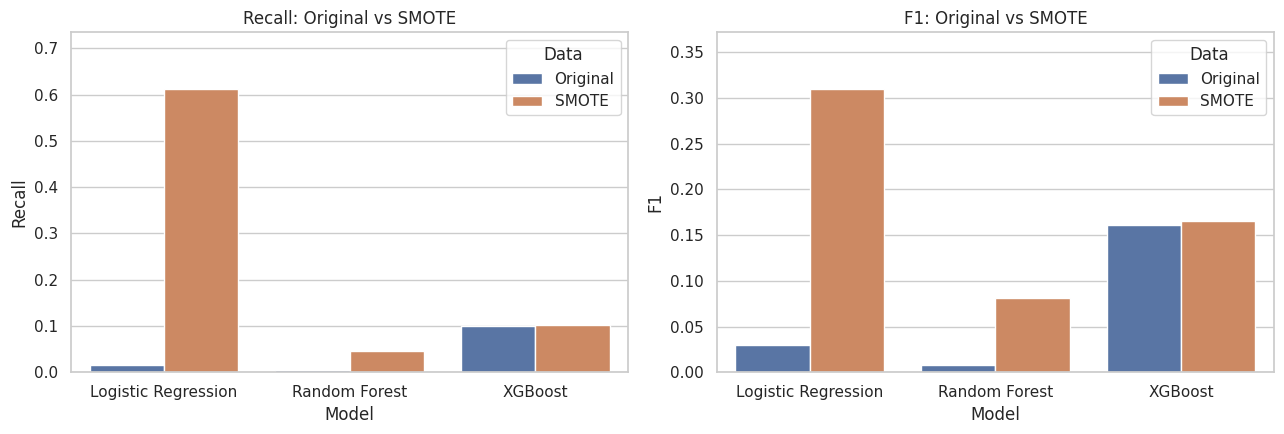

In [8]:
# Visualise the SMOTE effect on Recall and F1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["Recall", "F1"]):
    sns.barplot(data=table, x="Model", y=metric, hue="Data", ax=ax)
    ax.set_title(f"{metric}: Original vs SMOTE")
    ax.set_ylim(0, max(0.05, table[metric].max() * 1.2))
plt.tight_layout()
plt.savefig("../figures/12_smote_effect.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Pick the best model and test it


In [9]:
best_row = table.loc[table["F1"].idxmax()]
best_key = (best_row["Model"], best_row["Data"])
best_pipe = fitted[best_key]
print("Best model by validation F1:", best_key)

# Test-set performance
test_metrics = evaluate(best_pipe, X_test, y_test)
print("\nTest-set performance of the best model:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.3f}")

print("\nClassification report (test set):")
print(classification_report(y_test, best_pipe.predict(X_test),
                            target_names=["Not Fraud", "Fraud"], zero_division=0))

Best model by validation F1: ('Logistic Regression', 'SMOTE')

Test-set performance of the best model:
  Precision: 0.222
  Recall: 0.686
  F1: 0.335
  AUC-ROC: 0.726

Classification report (test set):
              precision    recall  f1-score   support

   Not Fraud       0.94      0.69      0.80      3984
       Fraud       0.22      0.69      0.34       516

    accuracy                           0.69      4500
   macro avg       0.58      0.69      0.57      4500
weighted avg       0.86      0.69      0.74      4500



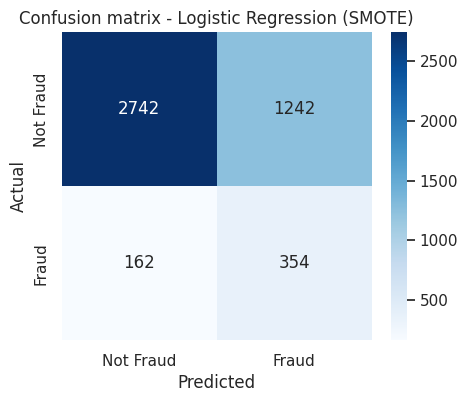

In [10]:
# Confusion matrix on the test set
cm = confusion_matrix(y_test, best_pipe.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.title(f"Confusion matrix - {best_key[0]} ({best_key[1]})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("../figures/13_confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()

### Confusion matrix for every model (test set)

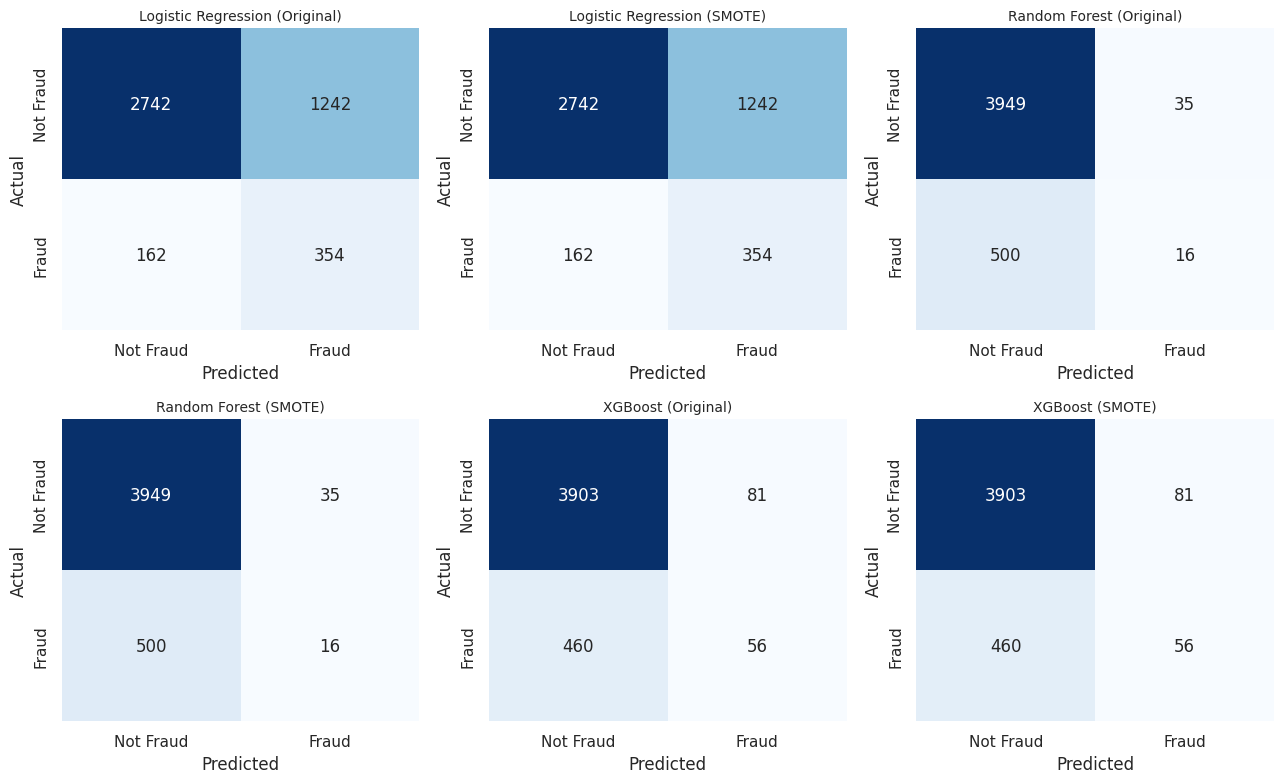

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (key, pipe) in zip(axes.ravel(), fitted.items()):
    cm_i = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm_i, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Not Fraud", "Fraud"],
                yticklabels=["Not Fraud", "Fraud"], ax=ax)
    ax.set_title("{} ({})".format(key[0], key[1]), fontsize=10)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("../figures/13b_confusion_all_models.png", dpi=110, bbox_inches="tight")
plt.show()

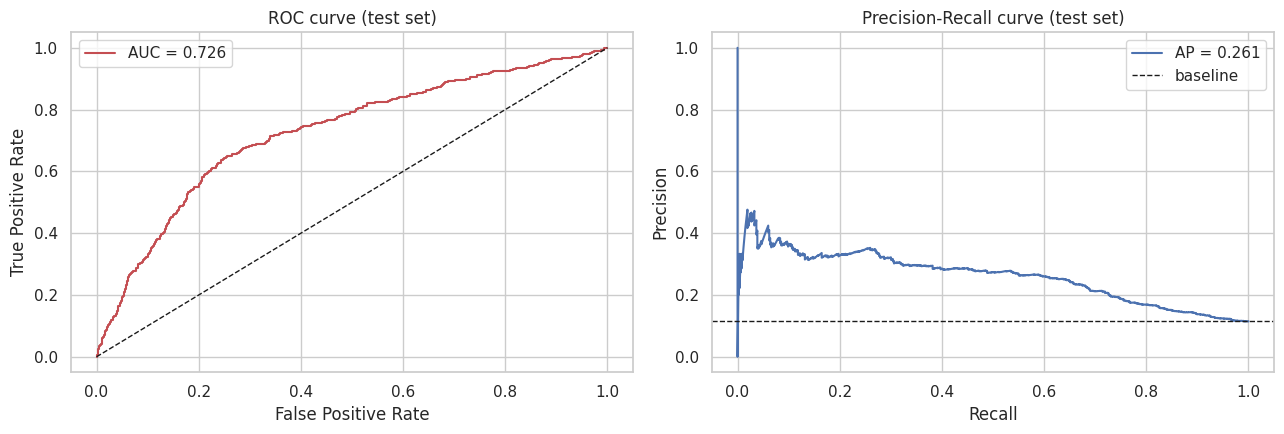

In [12]:
# ROC curve and Precision-Recall curve on the test set
proba_test = best_pipe.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC = {test_metrics['AUC-ROC']:.3f}", color="#C44E52")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curve (test set)")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(rec, prec, label=f"AP = {ap:.3f}", color="#4C72B0")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="baseline")
axes[1].set_title("Precision-Recall curve (test set)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/14_roc_pr_curves.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Explainability with SHAP

In [ ]:
import shap

prep_fitted = best_pipe.named_steps["prep"]
feature_names = prep_fitted.get_feature_names_out()

X_train_t = prep_fitted.transform(X_train)
X_test_t = prep_fitted.transform(X_test)

# If SMOTE was in the best pipeline
if "smote" in best_pipe.named_steps:
    X_train_t, y_train_res = best_pipe.named_steps["smote"].fit_resample(X_train_t, y_train)
else:
    y_train_res = y_train

# Train a fresh copy of the best classifier on the transformed data
best_clf_name = best_key[0]
shap_model = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                             eval_metric="logloss", random_state=RANDOM_STATE,
                             n_jobs=-1, tree_method="hist"),
}[best_clf_name]

# Densify if needed
import scipy.sparse as sp
if sp.issparse(X_train_t):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

shap_model.fit(X_train_t, y_train_res)

# Sample of the test set for SHAP
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test_t.shape[0], size=min(500, X_test_t.shape[0]), replace=False)
X_shap = X_test_t[sample_idx]

if best_clf_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap)

    # Random Forest returns a list 
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # Newer SHAP can return
    if hasattr(shap_values, "ndim") and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
else:
    explainer = shap.LinearExplainer(shap_model, X_train_t)
    shap_values = explainer.shap_values(X_shap)

print("SHAP values computed for", X_shap.shape[0], "claims.")

Background dataset has 37184 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=37184 when initializing the masker.


SHAP values computed for 500 claims.


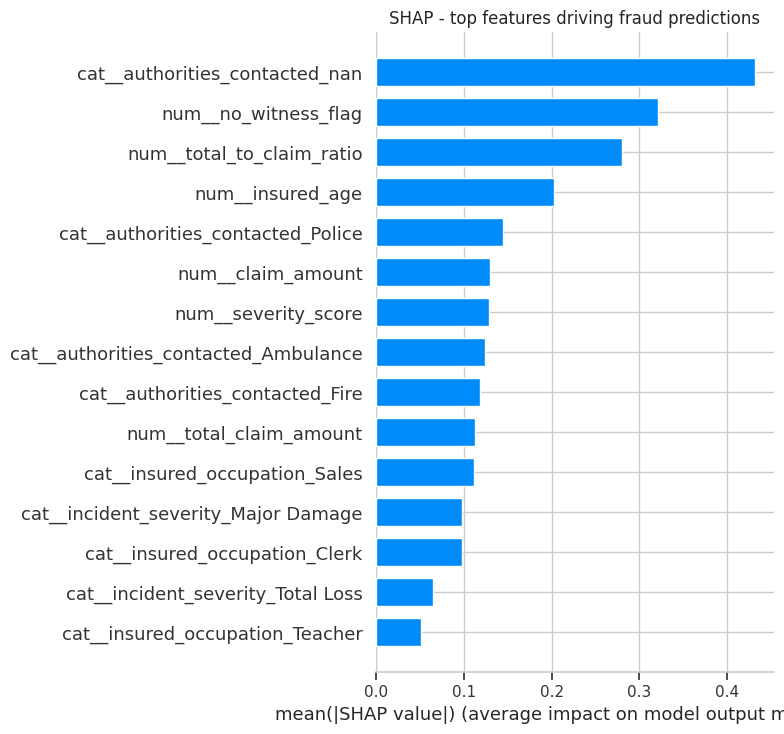

In [ ]:
# Global feature importance
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("SHAP - top features driving fraud predictions")
plt.tight_layout()
plt.savefig("../figures/15_shap_importance.png", dpi=110, bbox_inches="tight")
plt.show()

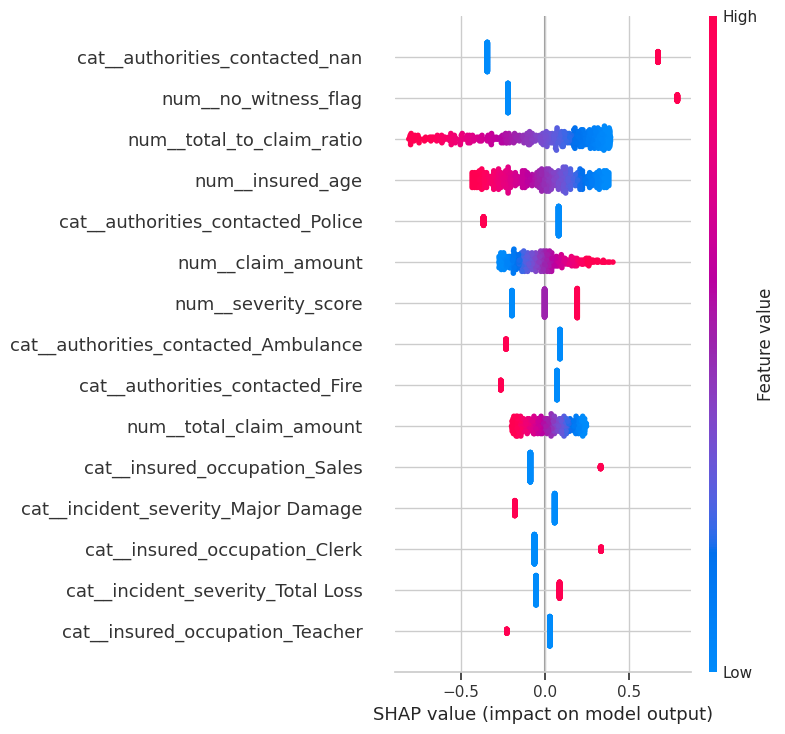

In [ ]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig("../figures/16_shap_beeswarm.png", dpi=110, bbox_inches="tight")
plt.show()

### Individual (local) SHAP explanations for representative claims


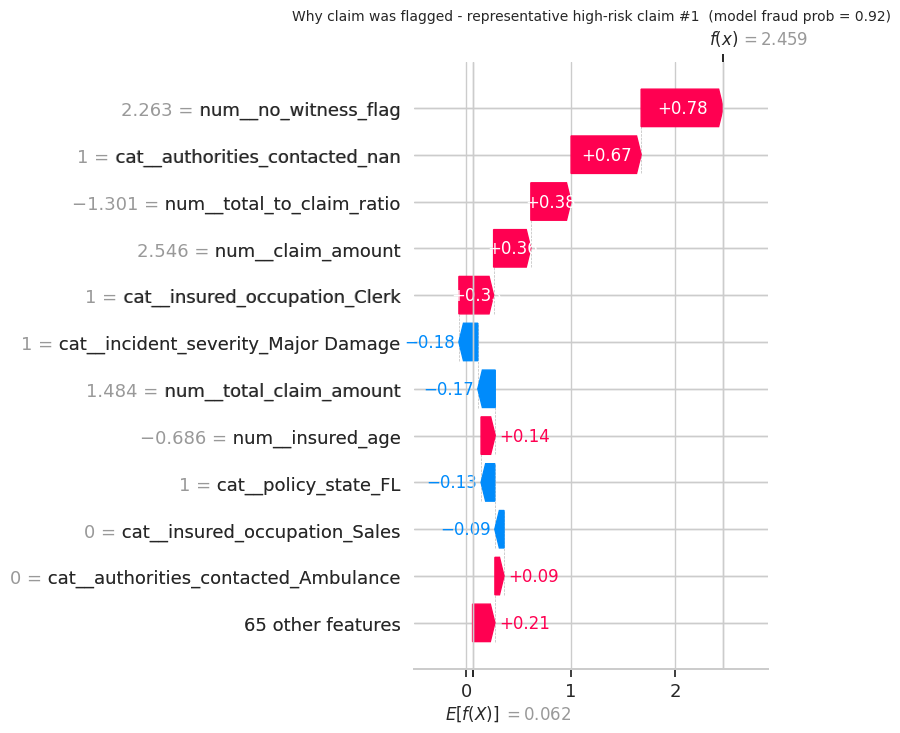

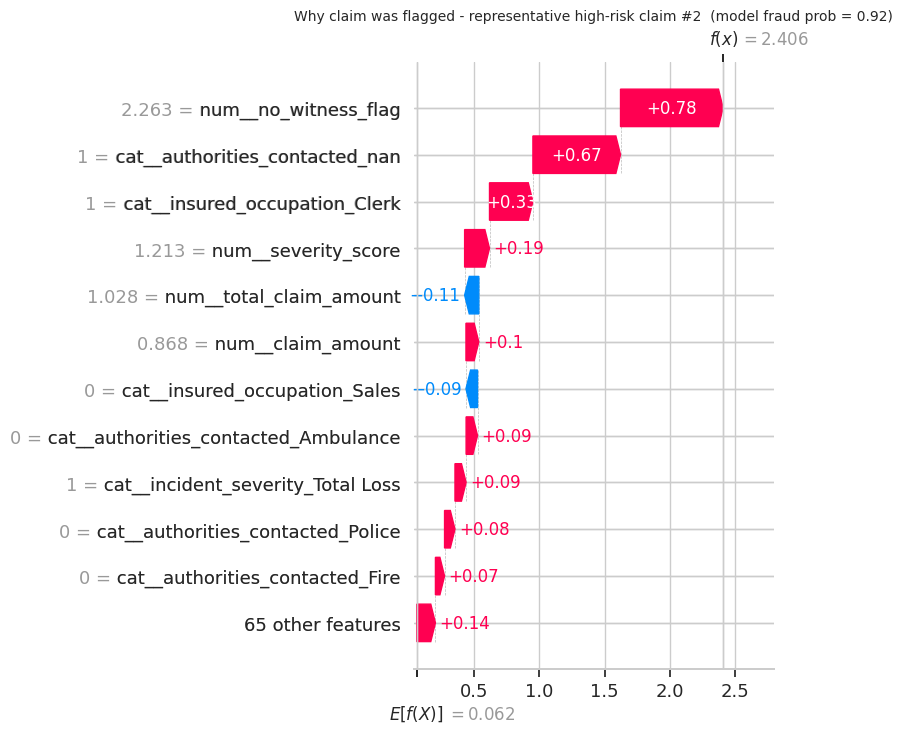

In [ ]:
# Rank the sampled claims by predicted fraud probability
sample_proba = shap_model.predict_proba(X_shap)[:, 1] if hasattr(shap_model, "predict_proba") else None
if sample_proba is None:
    order = np.argsort(-np.abs(shap_values).sum(axis=1))
else:
    order = np.argsort(-sample_proba)

# base value 
try:
    base_val = explainer.expected_value
    if hasattr(base_val, "__len__"):
        base_val = base_val[1] if len(base_val) > 1 else base_val[0]
except Exception:
    base_val = float(np.mean(shap_values))

for rank, idx in enumerate(order[:2], start=1):
    expl = shap.Explanation(
        values=shap_values[idx],
        base_values=base_val,
        data=X_shap[idx],
        feature_names=feature_names,
    )
    plt.figure()
    shap.plots.waterfall(expl, max_display=12, show=False)
    ttl = "Why claim was flagged - representative high-risk claim #{}".format(rank)
    if sample_proba is not None:
        ttl += "  (model fraud prob = {:.2f})".format(sample_proba[idx])
    plt.title(ttl, fontsize=10)
    plt.tight_layout()
    plt.savefig("../figures/{}_shap_waterfall_claim{}.png".format(20 + rank, rank),
                dpi=110, bbox_inches="tight")
    plt.show()

## 8. Fraud Risk Scoring system (rule-based, 0-100)

In [17]:
def risk_flags(data):
    """Return a points table from simple, human-readable red flags."""
    pts = pd.DataFrame(index=data.index)
    pts["total_loss"]        = (data["incident_severity"] == "Total Loss").astype(int) * 25
    pts["no_witness"]        = (data["witnesses"] == 0).astype(int) * 20
    pts["high_claim"]        = (data["claim_amount"] > data["claim_amount"].quantile(0.75)).astype(int) * 15
    pts["risky_occupation"]  = data["insured_occupation"].isin(["Sales", "Clerk"]).astype(int) * 15
    pts["young_claimant"]    = (data["insured_age"] < 30).astype(int) * 10
    pts["no_police_report"]  = (data["police_report_available"] == "No").astype(int) * 10
    pts["no_authority"]      = (data["authorities_contacted"] == "None").astype(int) * 5
    return pts


flag_points = risk_flags(df)
df["risk_score"] = flag_points.sum(axis=1)            # max possible = 100
df["risk_tier"] = pd.cut(df["risk_score"], bins=[-1, 24, 49, 100],
                         labels=["Low", "Medium", "High"])

print("Maximum possible score:", flag_points.sum(axis=1).max())
print("\nClaims in each risk tier:")
print(df["risk_tier"].value_counts())

Maximum possible score: 95

Claims in each risk tier:
risk_tier
Medium    13198
Low       12588
High       4214
Name: count, dtype: int64


  risk_tier  claims  actual_fraud_rate
0       Low   12588               8.33
1    Medium   13198              10.96
2      High    4214              22.43


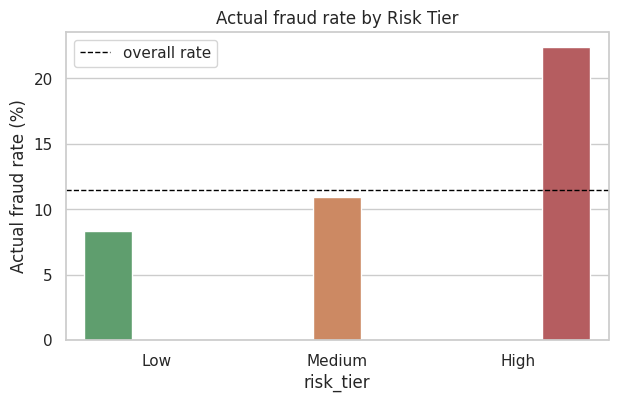

In [18]:
# Does the tier match the real fraud rate?
tier_summary = df.groupby("risk_tier", observed=True).agg(
    claims=("fraud", "size"),
    actual_fraud_rate=("fraud", "mean"),
).reset_index()
tier_summary["actual_fraud_rate"] = (tier_summary["actual_fraud_rate"] * 100).round(2)
print(tier_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=tier_summary, x="risk_tier", y="actual_fraud_rate",
            hue="risk_tier", legend=False, palette=["#55A868", "#DD8452", "#C44E52"])
plt.axhline(100 * df["fraud"].mean(), color="black", ls="--", lw=1, label="overall rate")
plt.title("Actual fraud rate by Risk Tier")
plt.ylabel("Actual fraud rate (%)")
plt.legend()
plt.savefig("../figures/17_risk_tiers.png", dpi=110, bbox_inches="tight")
plt.show()

In [19]:
# Cross-check: does the rule-based score agree with the model's probability?
df_scored = df.copy()
df_scored["model_proba"] = best_pipe.predict_proba(X)[:, 1]
corr_score_proba = df_scored["risk_score"].corr(df_scored["model_proba"])
print("Correlation between rule-based risk score and model probability: {:.3f}".format(corr_score_proba))

print("\nMean model probability by risk tier:")
print(df_scored.groupby("risk_tier", observed=True)["model_proba"].mean().round(3))

Correlation between rule-based risk score and model probability: 0.535

Mean model probability by risk tier:
risk_tier
Low       0.339
Medium    0.461
High      0.612
Name: model_proba, dtype: float64


## 9. Bias / fairness check across demographic groups

In [ ]:

test_dem = df.loc[X_test.index, ["insured_sex", "insured_age",
                                 "insured_education_level"]].copy()
test_dem["actual"] = y_test.values
test_dem["pred"] = best_pipe.predict(X_test)
test_dem["age_band"] = pd.cut(test_dem["insured_age"],
                              bins=[0, 30, 45, 60, 200],
                              labels=["<30", "30-44", "45-59", "60+"])


def group_fairness(frame, col):
    rows = []
    for g, sub in frame.groupby(col, observed=True):
        n = len(sub)
        actual_rate = sub["actual"].mean()
        flag_rate = sub["pred"].mean()
        # recall = caught frauds / real frauds in this group
        real_fraud = sub[sub["actual"] == 1]
        recall = (real_fraud["pred"] == 1).mean() if len(real_fraud) else np.nan
        rows.append({col: str(g), "n": n,
                     "actual_fraud_%": round(100 * actual_rate, 1),
                     "flag_rate_%": round(100 * flag_rate, 1),
                     "recall_%": round(100 * recall, 1) if recall == recall else None})
    return pd.DataFrame(rows)


for col in ["insured_sex", "age_band", "insured_education_level"]:
    print("\n=== Fairness by {} (test set) ===".format(col))
    print(group_fairness(test_dem, col).to_string(index=False))


=== Fairness by insured_sex (test set) ===
insured_sex    n  actual_fraud_%  flag_rate_%  recall_%
     FEMALE 1496            11.2         33.4      72.5
       MALE 1495            12.0         36.3      65.9
      OTHER 1509            11.3         36.7      67.6

=== Fairness by age_band (test set) ===
age_band    n  actual_fraud_%  flag_rate_%  recall_%
     <30 1015            13.6         47.3      71.0
   30-44 1126            11.4         38.4      70.3
   45-59 1184             9.8         31.3      68.1
     60+ 1175            11.4         26.6      64.9

=== Fairness by insured_education_level (test set) ===
insured_education_level    n  actual_fraud_%  flag_rate_%  recall_%
                College 1159            10.9         35.8      76.2
            High School 1157            11.9         33.9      67.4
                Masters 1072            11.4         35.3      62.3
                    PhD 1112            11.7         37.0      68.5


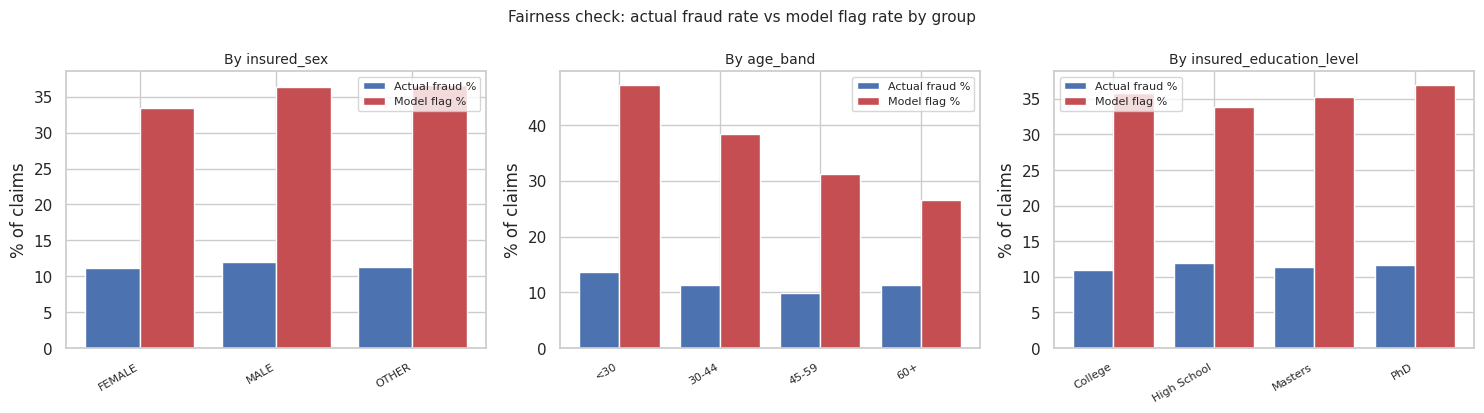

In [ ]:
#actual fraud rate vs model flag rate per group
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ["insured_sex", "age_band", "insured_education_level"]):
    gf = group_fairness(test_dem, col)
    xpos = np.arange(len(gf))
    ax.bar(xpos - 0.2, gf["actual_fraud_%"], width=0.4, label="Actual fraud %", color="#4C72B0")
    ax.bar(xpos + 0.2, gf["flag_rate_%"], width=0.4, label="Model flag %", color="#C44E52")
    ax.set_xticks(xpos); ax.set_xticklabels(gf[col], rotation=30, ha="right", fontsize=8)
    ax.set_title("By {}".format(col), fontsize=10)
    ax.set_ylabel("% of claims")
    ax.legend(fontsize=8)
plt.suptitle("Fairness check: actual fraud rate vs model flag rate by group", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/23_fairness_by_group.png", dpi=110, bbox_inches="tight")
plt.show()